In [1]:
#1.Imports and Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/sudan.csv")
df['Country'] = 'Sudan'

# Date Parsing
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month


In [ ]:
# Handle  missing values
df.replace(-999, np.nan, inplace=True)

# Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Missing Value Report
missing_pct = df.isna().mean() * 100
print("Missing Value Percentage:\n", missing_pct[missing_pct > 0])

# Summary Stats
df.describe()


Duplicates found: 0
Missing Value Percentage:
 Series([], dtype: float64)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


No duplicates were found , which means every columns are unique

In [4]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols].dropna()))

# Identify Z > 3
outliers = (z_scores > 3).sum()
print(f"Outlier counts per column:\n{outliers}")

# Cleaning: Forward-fill weather variables
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("../data/sudan_clean.csv", index=False)


Outlier counts per column:
91


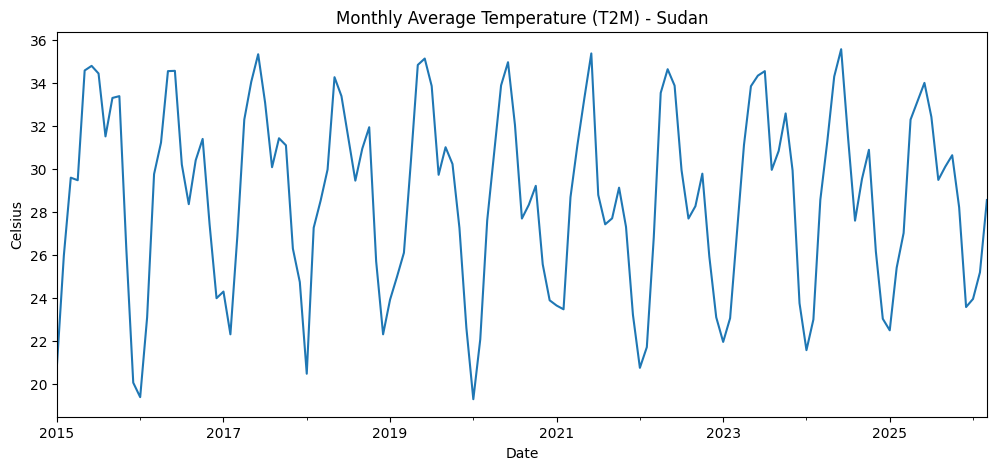

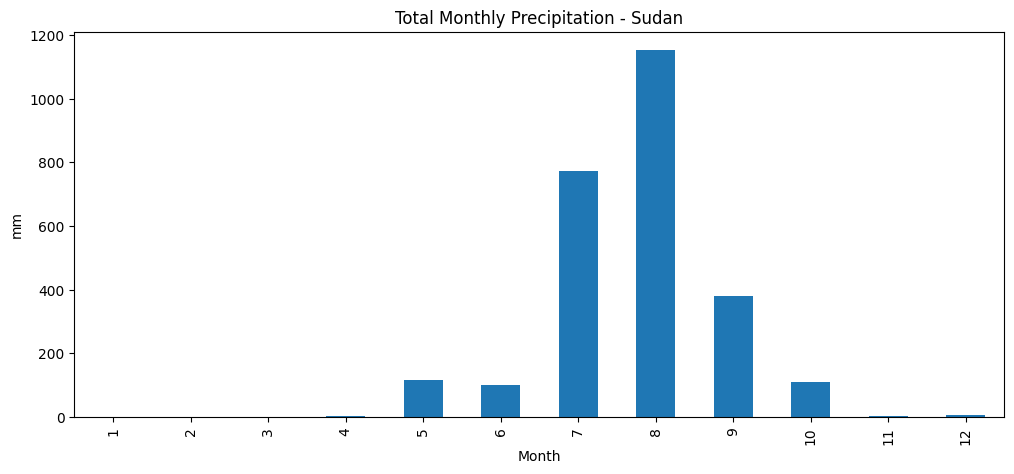

In [5]:
# Monthly Temp Line Chart
plt.figure(figsize=(12,5))
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
monthly_avg.plot(title="Monthly Average Temperature (T2M) - Sudan")
plt.ylabel("Celsius")
plt.show()

# Monthly Rainfall Bar Chart
plt.figure(figsize=(12,5))
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
monthly_rain.plot(kind='bar', title="Total Monthly Precipitation - Sudan")
plt.ylabel("mm")
plt.show()


TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: Jun 2024 - 35.6°C
★ Coolest Month: Jan 2020 - 19.3°C
📊 Temperature Range: 16.3°C
📈 Long-term Average: 28.7°C

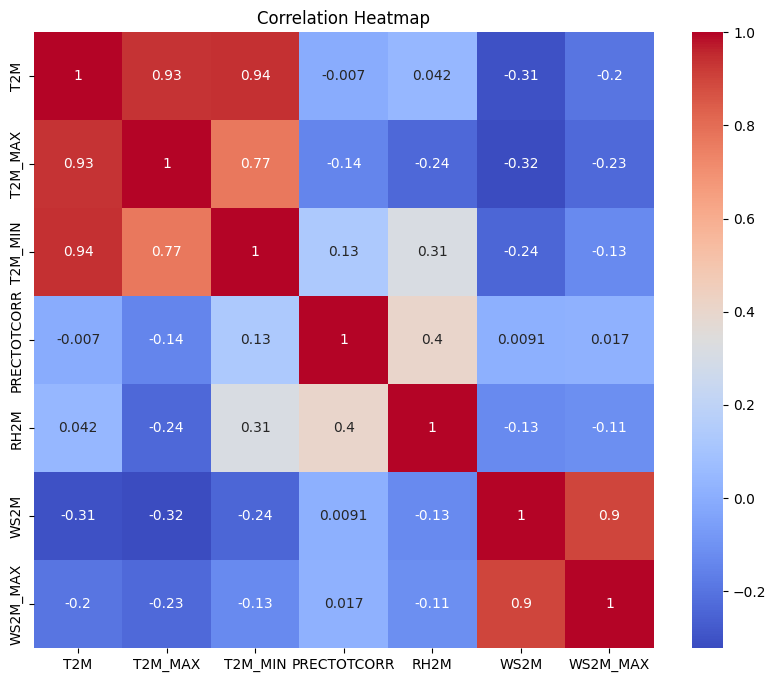

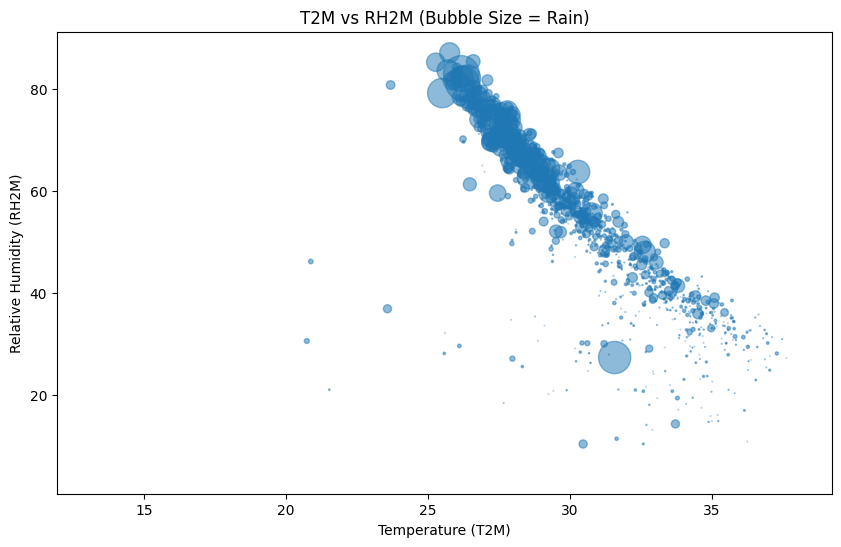

In [6]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Bubble Chart
plt.figure(figsize=(10,6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M (Bubble Size = Rain)")
plt.show()


📊 Key Climate Correlations
1. Time: Month vs. Day of Year (

)
The Link: A near-perfect mathematical lock.
Insight: This validates data integrity; as the days progress, the months follow exactly as expected.
2. Night Heat: Mean vs. Minimum Temp (

)
The Link: Daily averages are heavily dictated by nighttime lows.
Insight: Rising "cool" temperatures (warmer nights) are the primary driver of overall warming, which limits overnight recovery from heat stress.
3. Moisture: Relative vs. Specific Humidity (

)
The Link: Actual water vapor and relative saturation move in lockstep.
Insight: In this region, humidity levels are driven by the actual presence of moisture in the air rather than just temperature fluctuations.
4. Day Heat: Mean vs. Maximum Temp (

)
The Link: Daily averages closely track afternoon peaks.
Insight: When the mercury spikes at midday, the entire daily profile shifts upward, indicating consistent, sustained heat throughout the day